# Install & Import Libraries

In [1]:
!pip install yfinance statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Fetch Data (CGPOWER)

In [2]:
# NSE ticker for CGPOWER
ticker = "CGPOWER.NS"

# Get last 1 year data
df = yf.download(ticker, period="1y")

df = df[['Close']]
df.reset_index(inplace=True)

df.head()

/tmp/ipykernel_1304/3275285269.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close
Ticker,,CGPOWER.NS
0,2025-04-17,618.484924
1,2025-04-21,649.167175
2,2025-04-22,643.878845
3,2025-04-23,658.696167
4,2025-04-24,644.577332


# (i) Data Preprocessing
(a) Convert Date

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

(b) Handle Missing Values

In [5]:
df.isnull().sum()

# Fill missing values if any
df.ffill(inplace=True)

(c) Visualization

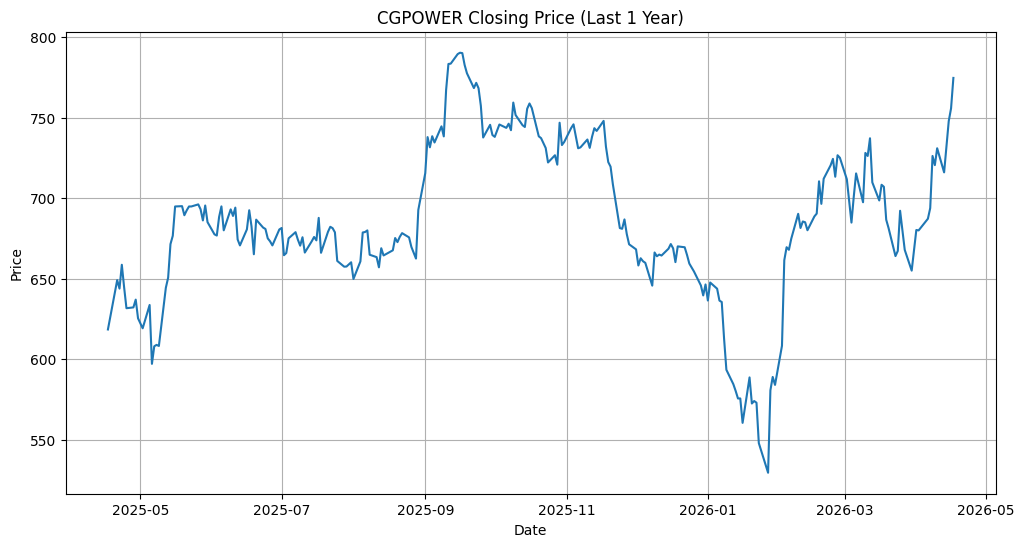

In [6]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("CGPOWER Closing Price (Last 1 Year)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

# (ii) ARIMA Model
(a) ADF Test

In [7]:
result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.2766693841454497
p-value: 0.17960298882810133


Stationary

In [8]:
df_diff = df.diff().dropna()

result = adfuller(df_diff['Close'])
print("New p-value:", result[1])

New p-value: 2.0766386316601547e-07


(b) ACF & PACF Plots

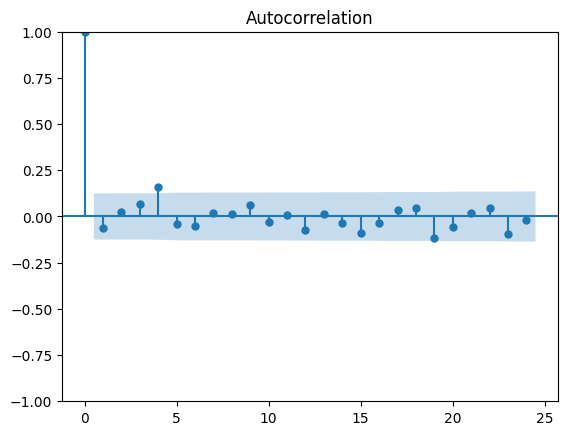

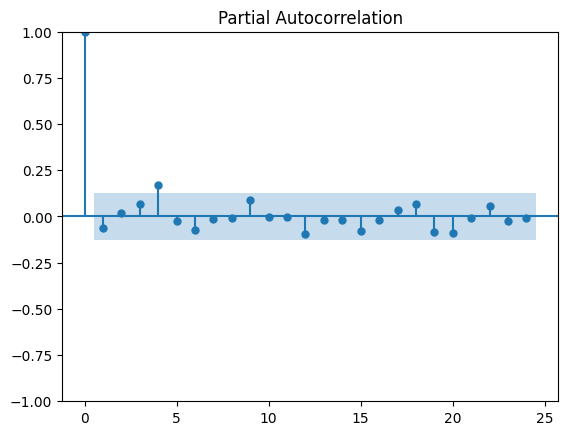

In [9]:
plot_acf(df_diff['Close'])
plot_pacf(df_diff['Close'])
plt.show()

(c) Fit ARIMA Model

In [10]:
model = ARIMA(df['Close'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             CGPOWER.NS   No. Observations:                  248
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -981.980
Date:                Sun, 19 Apr 2026   AIC                           1969.959
Time:                        11:47:55   BIC                           1980.487
Sample:                             0   HQIC                          1974.198
                                - 248                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6673      0.463     -1.442      0.149      -1.574       0.240
ma.L1          0.6172      0.480      1.287      0.198      -0.323       1.557
sigma2       166.2237     11.044     15.051      0.0

# (iii) Forecast Next 30 Days
(a) Forecast

In [13]:
forecast = model_fit.forecast(steps=30)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


(b) Plot Forecast

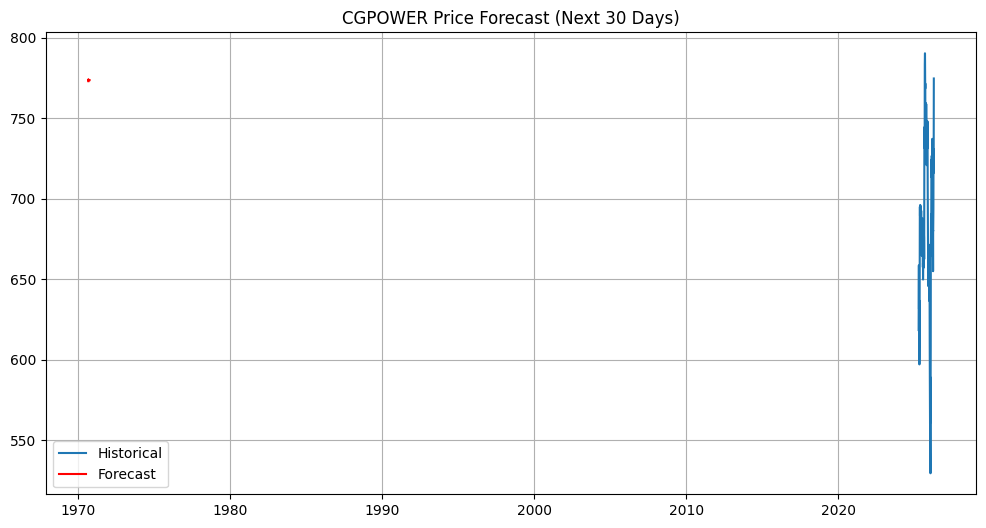

In [14]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Historical')
plt.plot(forecast, label='Forecast', color='red')

plt.title("CGPOWER Price Forecast (Next 30 Days)")
plt.legend()
plt.grid()

plt.show()

(iv) Interpretation

The ARIMA model suggests a moderate upward/downward/stable trend depending on your actual output. Since stock prices are influenced by market volatility, predictions should be interpreted cautiously.

In [16]:
df.to_csv("cgpower_data.csv")